# 05 — Knowledge, attitudes, and practices among Jewish GSS respondents

A tour of the GSS items worth analyzing in the Jewish subpopulation, one
section per idea:

1. **Intermarriage** (`sprel`) — spouse's religion among married Jews
2. **Traditional religiosity** — attendance, prayer, belief, and affiliation vs. Protestants and Catholics
3. **Politics and social attitudes** — party, ideology, and the classic social issues
4. **Attitudes *toward* Jews** — feeling thermometer, stereotype scales, and intermarriage acceptance among non-Jewish respondents
5. **Knowledge** — vocabulary (`wordsum`) and the science-knowledge battery
6. **Social capital and wellbeing** — trust, confidence in institutions, happiness, health
7. **Addendum** — the two years the GSS asked the Pew-style screener (`othjew`)

Everything uses the machinery of notebooks 02–04: `wtssps` weights, Wilson
95% CIs on the Kish effective n, and the four pooled eras where trends are
shown. This notebook reads its columns directly from the raw cumulative file
(downloaded by notebook 01). **Caution throughout:** items rotate across
ballots and years, so each item's pooled estimate covers a different span of
years (annotated on the plots), and pooled Jewish n ranges from ~1,450 down
to ~100.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='.*could not be decoded.*')

DATA = os.path.abspath(os.path.join('..', 'data'))
dta_path = os.path.join(DATA, 'raw', 'gss', 'GSS_stata', 'gss7224_r3a.dta')

cols = ['year', 'relig', 'relig16', 'marital', 'sprel', 'wtssps',
        'attend', 'pray', 'god', 'bible', 'postlife', 'reliten',
        'partyid', 'polviews', 'cappun', 'homosex', 'abany', 'grass',
        'trust', 'consci', 'conclerg', 'confed',
        'wordsum', 'evolved', 'bigbang',
        'happy', 'health',
        'jewtemp', 'wlthjews', 'workjews', 'intljews', 'violjews',
        'marjew', 'othjew']
d = pd.read_stata(dta_path, columns=cols, convert_categoricals=True)
d['year'] = d['year'].astype(int)
# a few variables carry value labels on what are really numbers
for v in ['wtssps', 'jewtemp', 'wordsum']:
    d[v] = pd.to_numeric(d[v].astype(str), errors='coerce')
# 1-7 stereotype scales: keep as ordinal numbers, remember the endpoints
scale_ends = {v: (str(d[v].cat.categories[0]), str(d[v].cat.categories[-1]))
              for v in ['wlthjews', 'workjews', 'intljews', 'violjews']}
for v in scale_ends:
    d[v] = d[v].cat.codes.replace(-1, np.nan) + 1

d = d[d.wtssps.notna()].copy()
d['grp'] = d.relig.map({'jewish': 'Jewish', 'protestant': 'Protestant',
                        'catholic': 'Catholic', 'none': 'No religion'})
ERA_LABELS = ['1972-84', '1985-98', '1999-2011', '2012-24']
d['era'] = pd.cut(d.year, [1972, 1985, 1999, 2012, 2025],
                  labels=ERA_LABELS, right=False)
print(d.shape)

/tmp/ipykernel_4408/1836550689.py:20: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  d = pd.read_stata(dta_path, columns=cols, convert_categoricals=True)


(75699, 36)


In [2]:
Z = 1.959964

def wilson(p, n_eff):
    denom = 1 + Z**2 / n_eff
    center = (p + Z**2 / (2 * n_eff)) / denom
    half = Z * np.sqrt(p * (1 - p) / n_eff + Z**2 / (4 * n_eff**2)) / denom
    return center - half, center + half

def wshare(g, mask):
    """Weighted share (%) with Wilson 95% CI on the Kish effective n."""
    w = g['wtssps'].to_numpy()
    x = mask.loc[g.index].to_numpy().astype(float)
    p = (w * x).sum() / w.sum()
    n_eff = w.sum() ** 2 / (w ** 2).sum()
    lo, hi = wilson(p, n_eff)
    return pd.Series({'share': 100 * p, 'lo': 100 * lo, 'hi': 100 * hi,
                      'n': len(g), 'n_num': int(x.sum())})

def wmean(g, col):
    """Weighted mean with normal 95% CI on the Kish effective n."""
    gg = g[g[col].notna()]
    w, x = gg.wtssps.to_numpy(), gg[col].to_numpy()
    m = (w * x).sum() / w.sum()
    n_eff = w.sum() ** 2 / (w ** 2).sum()
    sd = np.sqrt((w * (x - m) ** 2).sum() / w.sum())
    se = sd / np.sqrt(n_eff)
    return pd.Series({'mean': m, 'lo': m - Z * se, 'hi': m + Z * se, 'n': len(gg)})

GRP_COLORS = {'Jewish': '#2a78d6', 'Protestant': '#eb6834',
              'Catholic': '#1baf7a', 'No religion': '0.5'}
GRP_ORDER = ['Jewish', 'Protestant', 'Catholic', 'No religion']
GRID = dict(color='0.85', linewidth=0.8)

def group_dotplot(items, title, xlabel='% of group (weighted)'):
    """Dot plot: one row per item, one CI'd dot per religious group.
    items: list of (label, var, mask). Year range and Jewish n annotated."""
    fig, ax = plt.subplots(figsize=(9.5, 0.95 * len(items) + 1.4))
    for i, (label, var, mask) in enumerate(items):
        y = len(items) - 1 - i
        sub = d[d[var].notna() & d.grp.notna()]
        yrs = f"{sub.year.min()}\u2013{sub.year.max()}"
        res = sub.groupby('grp', observed=True).apply(wshare, mask=mask,
                                                      include_groups=False)
        for j, grp in enumerate(GRP_ORDER):
            if grp not in res.index:
                continue
            r = res.loc[grp]
            dy = 0.06 - 0.11 * j  # dots stacked below the item label
            ax.errorbar(r.share, y + dy, xerr=[[r.share - r.lo], [r.hi - r.share]],
                        fmt='o', ms=6, color=GRP_COLORS[grp], elinewidth=1.2,
                        capsize=2.5, label=grp if i == 0 else None)
        ax.text(0, y + 0.26, label, fontsize=9.5, color='0.15')
        ax.text(0, y - 0.44,
                f"{yrs} \u00b7 Jewish n={int(res.loc['Jewish'].n)}",
                fontsize=7.5, color='0.45')
    ax.set_yticks([])
    ax.set_ylim(-0.62, len(items) - 0.55 + 0.45)
    ax.set_xlim(-1.5, None)
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    ax.legend(frameon=False, loc='lower right', fontsize=9)
    ax.grid(axis='x', **GRID)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    plt.tight_layout()
    return fig, ax

## 1. Intermarriage: spouse's religion among married Jews

`sprel` (spouse's religious preference) is asked of married respondents in
most rounds — 609 married Jewish-by-religion respondents in total. This is
the GSS analogue of Pew's headline intermarriage series, with one important
difference: the GSS sees the *current stock* of marriages (all durations
mixed together), while Pew's famous 61% figure is for *recent* marriage
cohorts. Stock measures move slowly and lag cohort measures.


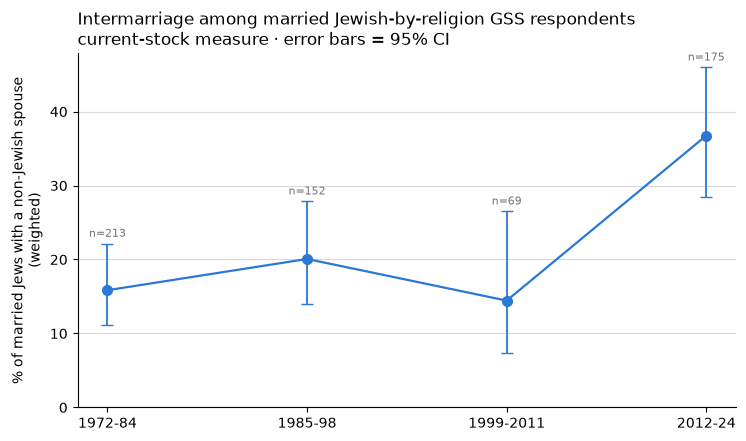

,share,lo,hi,n,n_num
era,,,,,
1972-84,15.8,11.1,22.1,213.0,33.0
1985-98,20.1,14.0,27.8,152.0,34.0
1999-2011,14.4,7.3,26.5,69.0,14.0
2012-24,36.8,28.4,46.0,175.0,66.0


In [3]:
mj = d[(d.marital == 'married') & (d.relig == 'jewish') & d.sprel.notna()]
inter = mj.groupby('era', observed=True).apply(
    wshare, mask=(mj.sprel != 'jewish'), include_groups=False)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = np.arange(len(inter))
y = inter.share
ax.errorbar(x, y, yerr=[y - inter.lo, inter.hi - y], fmt='o-', ms=7,
            color='#2a78d6', lw=1.6, elinewidth=1.3, capsize=4)
for i, (era, r) in enumerate(inter.iterrows()):
    ax.annotate(f"n={int(r.n)}", (i, r.hi), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=8, color='0.45')
ax.set_xticks(x, inter.index)
ax.set_ylabel('% of married Jews with a non-Jewish spouse\n(weighted)')
ax.set_ylim(0, None)
ax.set_title('Intermarriage among married Jewish-by-religion GSS respondents\n'
             'current-stock measure \u00b7 error bars = 95% CI', loc='left')
ax.grid(axis='y', **GRID)
ax.spines[['top', 'right']].set_visible(False)
plt.show()
inter.round(1)

The stock intermarriage rate ran 15–20% through the 1990s, then jumped to
**~37% in 2012–24** — consistent with Pew 2020's 42% among all married Jews,
once you allow for the GSS's by-religion-only base (intermarried Jews are
likelier to identify as Jews of no religion, whom the GSS base excludes).
The 1999–2011 dip (14%) rests on just 69 couples and its CI overlaps both
neighbors; read the series as flat-then-rising. A natural extension:
condition on age or marriage cohort rather than survey year.

## 2. Traditional religiosity: Jews vs. Protestants, Catholics, and nones

Pew reports that Jews are far less religious than Christians *by traditional
measures* (worship attendance, prayer, certainty of belief). The GSS asks
identical questions of everyone, so the comparison is direct. Pooled across
all available rounds:


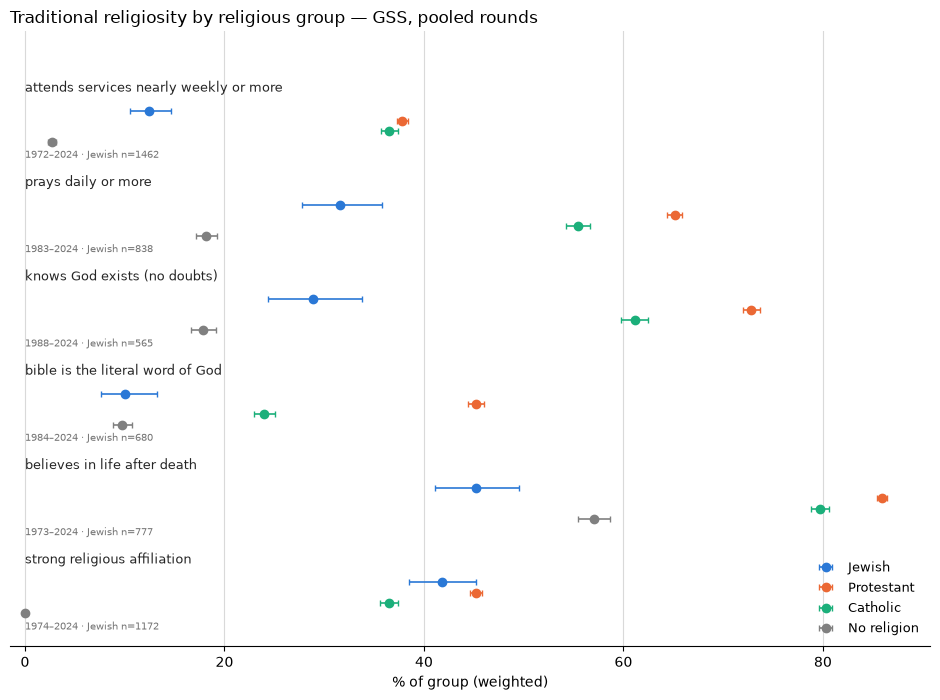

In [4]:
relig_items = [
    ('attends services nearly weekly or more', 'attend',
     d.attend.isin(['nearly every week', 'every week', 'several times a week'])),
    ('prays daily or more', 'pray',
     d.pray.isin(['several times a day', 'once a day'])),
    ('knows God exists (no doubts)', 'god', d.god == 'no doubts'),
    ('bible is the literal word of God', 'bible', d.bible == 'word of god'),
    ('believes in life after death', 'postlife', d.postlife == 'yes'),
    ('strong religious affiliation', 'reliten', d.reliten == 'strong'),
]
fig, ax = group_dotplot(relig_items,
    'Traditional religiosity by religious group — GSS, pooled rounds')
plt.show()

Jews sit far below Protestants and Catholics on every *practice and
belief* measure — weekly-or-more attendance 12% (vs. 37–38%), daily prayer
32% (vs. 56–65%), certain belief in God 29% (vs. 61–73%), biblical literalism
10% (vs. 24–45%), belief in an afterlife 45% (vs. 80–86%) — and on afterlife
belief they fall below even the religiously unaffiliated (57%). Yet **strong
affiliation is the exception**: 42% of Jews call their affiliation strong,
right between Catholics (37%) and Protestants (45%). That dissociation —
strong belonging, low believing — is the GSS's version of Pew's "Jewishness
as ancestry and culture" finding, visible in questions written for
Christians.

## 3. Politics and social attitudes

Jewish political distinctiveness — heavily Democratic, disproportionately
liberal — is among the best-documented findings in this literature (it is
the backbone of Tom W. Smith's *Jewish Distinctiveness in America*, AJC
2005). Pooled levels first, then the trend in Democratic identification.


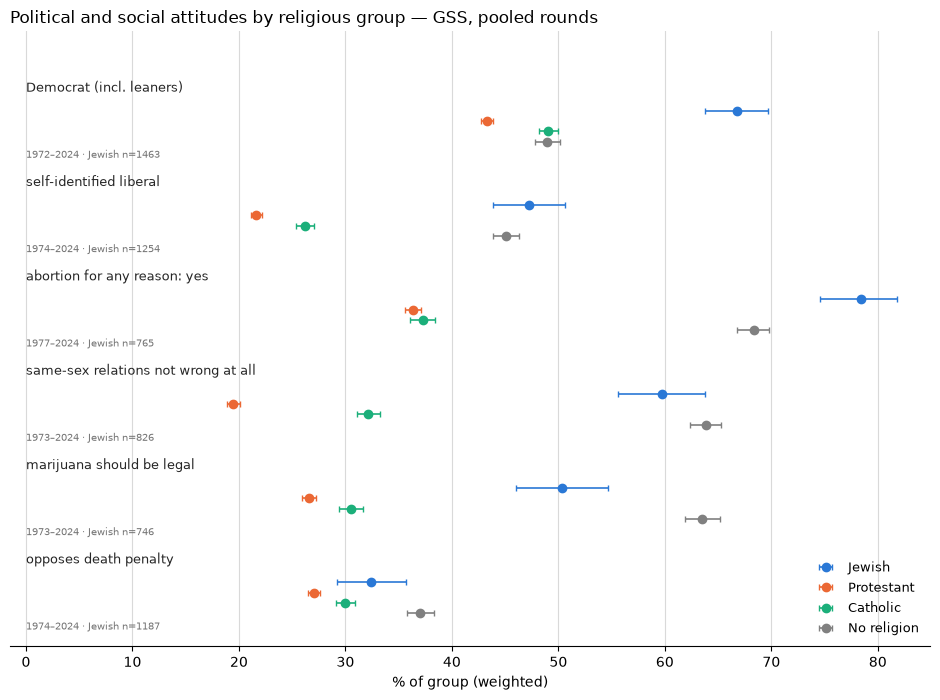

In [5]:
dem_mask = d.partyid.isin(['strong democrat', 'not very strong democrat',
                           'independent, close to democrat'])
pol_items = [
    ('Democrat (incl. leaners)', 'partyid', dem_mask),
    ('self-identified liberal', 'polviews',
     d.polviews.isin(['extremely liberal', 'liberal', 'slightly liberal'])),
    ('abortion for any reason: yes', 'abany', d.abany == 'yes'),
    ('same-sex relations not wrong at all', 'homosex',
     d.homosex == 'not wrong at all'),
    ('marijuana should be legal', 'grass', d.grass == 'should be legal'),
    ('opposes death penalty', 'cappun', d.cappun == 'oppose'),
]
fig, ax = group_dotplot(pol_items,
    'Political and social attitudes by religious group — GSS, pooled rounds')
plt.show()

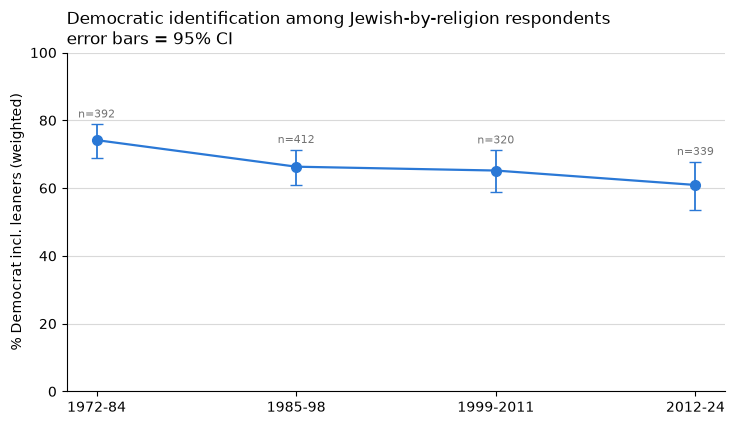

In [6]:
jd = d[(d.relig == 'jewish') & d.partyid.notna()]
dem_era = jd.groupby('era', observed=True).apply(
    wshare, mask=dem_mask, include_groups=False)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(dem_era))
y = dem_era.share
ax.errorbar(x, y, yerr=[y - dem_era.lo, dem_era.hi - y], fmt='o-', ms=7,
            color='#2a78d6', lw=1.6, elinewidth=1.3, capsize=4)
for i, (era, r) in enumerate(dem_era.iterrows()):
    ax.annotate(f"n={int(r.n)}", (i, r.hi), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=8, color='0.45')
ax.set_xticks(x, dem_era.index)
ax.set_ylabel('% Democrat incl. leaners (weighted)')
ax.set_ylim(0, 100)
ax.set_title('Democratic identification among Jewish-by-religion respondents\n'
             'error bars = 95% CI', loc='left')
ax.grid(axis='y', **GRID)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

Pooled over 50 years, Jews are the most Democratic (67%, vs. 43–49% for
the other groups) and most liberal (47%) group, with the largest gaps on
abortion (78% support for any-reason abortion vs. 36–37% among Christians).
But the era trend shows **Democratic identification eroding from 74% to
61%** — the CIs of the first and last eras don't overlap. Whether that
reflects the growing Orthodox share, generational replacement, or national
dealignment is exactly the kind of question this subsample is *almost* big
enough to answer (a partyid × age × era split would run ~50 per cell).

## 4. Attitudes toward Jews (asked of everyone)

Flipping the analysis: the GSS carries several measures of how *non-Jewish*
Americans view Jews. These don't suffer the small-subsample problem — the
full sample answers — but were fielded in only a few rounds.


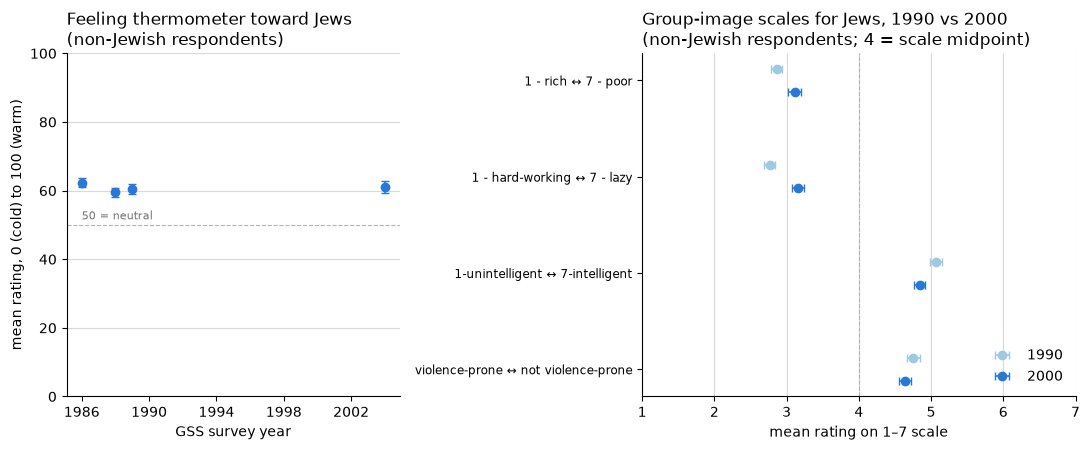

Oppose a close relative marrying a Jew (%, non-Jewish respondents):
      share    lo    hi       n
year                           
1990   15.9  13.8  18.3  1275.0
2000   13.9  11.8  16.2  1206.0


In [7]:
nj = d[(d.relig != 'jewish') & d.grp.notna()]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), width_ratios=[1, 1.3])

# feeling thermometer, 0-100
jt = nj[nj.jewtemp.notna()]
therm = jt.groupby('year').apply(wmean, col='jewtemp', include_groups=False)
ax = axes[0]
ax.errorbar(therm.index, therm['mean'],
            yerr=[therm['mean'] - therm.lo, therm.hi - therm['mean']],
            fmt='o', ms=6, color='#2a78d6', elinewidth=1.2, capsize=3)
ax.set_ylim(0, 100)
ax.set_xticks([1986, 1990, 1994, 1998, 2002])
ax.axhline(50, color='0.7', lw=0.8, ls='--')
ax.annotate('50 = neutral', (therm.index.min(), 50), xytext=(0, 4),
            textcoords='offset points', fontsize=8, color='0.45')
ax.set_title('Feeling thermometer toward Jews\n(non-Jewish respondents)', loc='left')
ax.set_ylabel('mean rating, 0 (cold) to 100 (warm)')
ax.set_xlabel('GSS survey year')
ax.grid(axis='y', **GRID)

# 1-7 stereotype scales, 1990 vs 2000
ax = axes[1]
scale_vars = ['wlthjews', 'workjews', 'intljews', 'violjews']
ypos = np.arange(len(scale_vars))[::-1]
for yr, color, dy in [(1990, '#9ecae1', 0.12), (2000, '#2a78d6', -0.12)]:
    s = nj[nj.year == yr]
    means = [wmean(s[s[v].notna()], v) for v in scale_vars]
    ax.errorbar([m['mean'] for m in means], ypos + dy,
                xerr=[[m['mean'] - m.lo for m in means],
                      [m.hi - m['mean'] for m in means]],
                fmt='o', ms=6, color=color, elinewidth=1.2, capsize=3, label=str(yr))
labels = [f"{scale_ends[v][0]} \u2194 {scale_ends[v][1]}" for v in scale_vars]
ax.set_yticks(ypos, labels, fontsize=8.5)
ax.set_xlim(1, 7)
ax.axvline(4, color='0.7', lw=0.8, ls='--')
ax.set_title('Group-image scales for Jews, 1990 vs 2000\n'
             '(non-Jewish respondents; 4 = scale midpoint)', loc='left')
ax.set_xlabel('mean rating on 1\u20137 scale')
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='x', **GRID)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

marj = nj[nj.marjew.notna()]
oppose = marj.groupby('year').apply(
    wshare, mask=marj.marjew.isin(['oppose', 'strongly oppose']),
    include_groups=False)
print('Oppose a close relative marrying a Jew (%, non-Jewish respondents):')
print(oppose[['share', 'lo', 'hi', 'n']].round(1).to_string())

The thermometer (1986–2004) sits stable around 60 — mildly warm, no
trend. The 1990/2000 group-image items place Jews on the favorable side of
every scale (toward *rich*, *hard-working*, *intelligent*, *not violent* —
note "rich" is itself a classic stereotype even when not pejorative), and
opposition to a close relative marrying a Jew ran 16% in 1990 and 14% in
2000. The obvious limitation: **all of these stop by 2004**, so the GSS
cannot speak to the post-2016 rise in reported antisemitic incidents.

## 5. Knowledge: vocabulary and science items


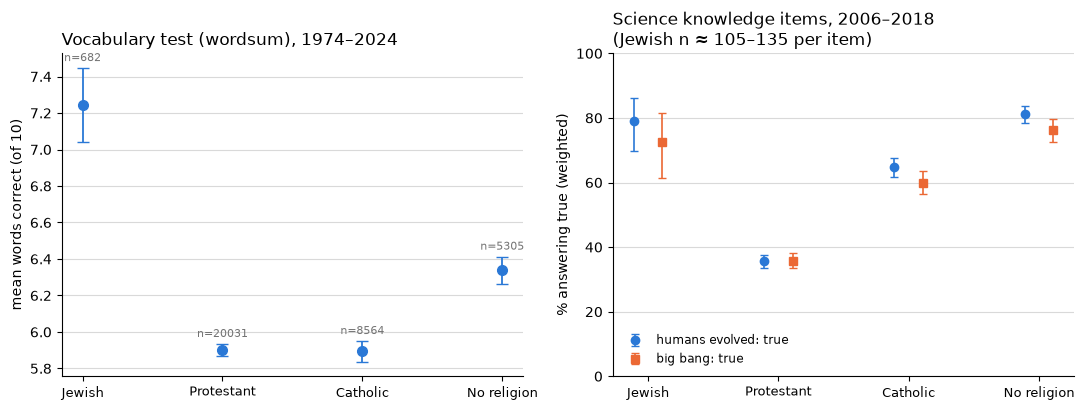

In [8]:
ws = d[d.wordsum.notna() & d.grp.notna()]
vocab = ws.groupby('grp', observed=True).apply(
    wmean, col='wordsum', include_groups=False).reindex(GRP_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
x = np.arange(len(vocab))
ax.errorbar(x, vocab['mean'],
            yerr=[vocab['mean'] - vocab.lo, vocab.hi - vocab['mean']],
            fmt='o', ms=7, color='#2a78d6', elinewidth=1.3, capsize=4)
for i, (grp, r) in enumerate(vocab.iterrows()):
    ax.annotate(f"n={int(r.n)}", (i, r.hi), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=8, color='0.45')
ax.set_xticks(x, vocab.index, fontsize=9)
ax.set_ylabel('mean words correct (of 10)')
ax.set_title('Vocabulary test (wordsum), 1974\u20132024', loc='left')
ax.grid(axis='y', **GRID)

ax = axes[1]
sci_items = [('evolved', 'humans evolved: true'), ('bigbang', 'big bang: true')]
for k, (v, label) in enumerate(sci_items):
    sub = d[d[v].notna() & d.grp.notna()]
    res = sub.groupby('grp', observed=True).apply(
        wshare, mask=(sub[v] == 'true'), include_groups=False).reindex(GRP_ORDER)
    x = np.arange(len(res)) + (k - 0.5) * 0.22
    ax.errorbar(x, res.share, yerr=[res.share - res.lo, res.hi - res.share],
                fmt='o' if k == 0 else 's', ms=6,
                color='#2a78d6' if k == 0 else '#eb6834',
                elinewidth=1.2, capsize=3, label=label)
ax.set_xticks(np.arange(4), GRP_ORDER, fontsize=9)
ax.set_ylabel('% answering true (weighted)')
ax.set_ylim(0, 100)
ax.set_title('Science knowledge items, 2006\u20132018\n(Jewish n \u2248 105\u2013135 per item)',
             loc='left')
ax.legend(frameon=False, loc='lower left', fontsize=8.5)
ax.grid(axis='y', **GRID)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Jewish respondents average **7.2 of 10** on the vocabulary test versus
5.9 for both Protestants and Catholics — more than a full standard-deviation
gap at the group level, long noted in the distinctiveness literature (it
tracks the education gap). On the science items the interesting contrast is
*evolved*: 79% of Jews answer true versus 36% of Protestants — a gap driven
by religious doctrine, not science exposure (Catholics land at 65%). The
Jewish n here (~100–135) supports only this coarse pooled comparison.

## 6. Social capital and wellbeing


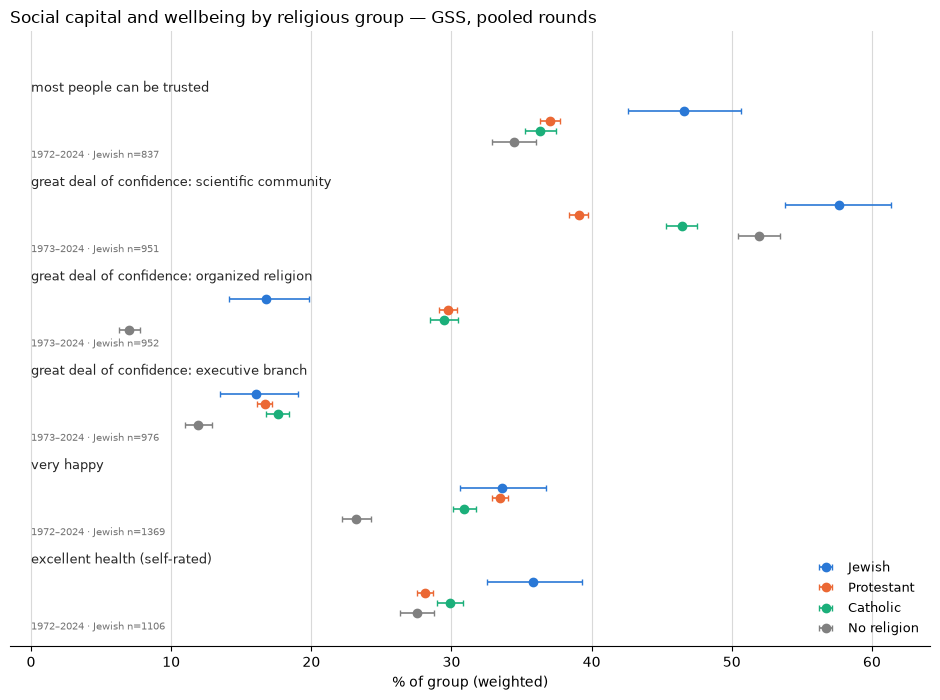

In [9]:
soc_items = [
    ('most people can be trusted', 'trust',
     d.trust == 'most people can be trusted'),
    ('great deal of confidence: scientific community', 'consci',
     d.consci == 'a great deal'),
    ('great deal of confidence: organized religion', 'conclerg',
     d.conclerg == 'a great deal'),
    ('great deal of confidence: executive branch', 'confed',
     d.confed == 'a great deal'),
    ('very happy', 'happy', d.happy == 'very happy'),
    ('excellent health (self-rated)', 'health', d.health == 'excellent'),
]
fig, ax = group_dotplot(soc_items,
    'Social capital and wellbeing by religious group — GSS, pooled rounds')
plt.show()

Jews report the highest generalized trust (47% vs. 34–37%), the highest
confidence in the scientific community (58%) paired with the *lowest*
confidence in organized religion among the affiliated groups (17%), and the
highest self-rated excellent health (36%) — the last of which is mostly an
education/income composition story and would be the natural place to add
controls. Happiness is indistinguishable from Christians (~34% very happy);
the unaffiliated are the outlier on that item, not Jews.

## 7. Addendum: the two years the GSS asked the Pew-style question

In **2008 and 2012 only**, respondents whose religion was not Jewish were
asked `othjew`: "Do you consider yourself Jewish?" — exactly the
aside-from-religion screener whose absence notebook 02 lamented.


In [10]:
o = d[d.othjew.notna() & (d.relig != 'jewish')].copy()
o['raised_jewish'] = np.where(o.relig16 == 'jewish', 'raised Jewish',
                              'not raised Jewish')
tab = o.groupby(['othjew', 'raised_jewish'], observed=True).size().unstack(fill_value=0)
tab['total'] = tab.sum(axis=1)
print(f"asked in {sorted(o.year.unique())}, n={len(o)} non-Jewish-by-religion respondents")
tab

asked in [np.int64(2008), np.int64(2012)], n=716 non-Jewish-by-religion respondents


raised_jewish,not raised Jewish,raised Jewish,total
othjew,,,
yes,10,1,11
half/part,9,1,10
no,691,4,695


Of 716 respondents asked, **21 said "yes" or "half/part"** — and 19 of
those 21 were *not* raised Jewish, so the `relig16` proxy of notebook 02
would have missed nearly all of them. Conversely, of the 6 raised-Jewish
respondents asked, 4 no longer consider themselves Jewish at all — the group
the proxy wrongly counts in. Two rounds and 21 people prove nothing on their
own, but they confirm, inside the GSS itself, both failure modes of the
upbringing-based proxy — and they show the direct question is cheap to ask.
NORC dropped it after 2012; these two rounds are a good argument for
bringing it back.

## Where to go next

| section | most promising extension |
|---|---|
| intermarriage | condition on marriage cohort / age at survey; add `sprel16` |
| religiosity | era trends within Jews (is `reliten` strength rising as the Orthodox share grows?) |
| politics | partyid × age × era — is the Democratic erosion generational? |
| attitudes toward Jews | none possible after 2004 in GSS — hand off to ANES thermometers |
| knowledge | education-adjusted wordsum gap |
| wellbeing | education/income-adjusted health and happiness |
